# Does pro-side maturity data predict audience-era findings better than milestone_year does?

**Purpose**: cashes in a promise this project made to itself and never
tested. `post_3_anatomy_of_a_network/brief.md`'s framing-caveat section
(2026-09-25) states that `milestone_year` -- the earliest
2-consecutive-year window of top-tier tournament activity spanning 2+
continents -- is a **lagging** indicator of network maturity, not the
maturation event itself, and points at `mode_of_engagement_model/brief.md`'s
engagement ladder (Play -> Elite Play -> **Professionalised Play** ->
**Watch** -> Socialise -> Attend -> Purchase) as the real framework --
explicitly flagging that this post's era hypothesis measures *when
professionalization happened*, not *when the network matured*, and that
a fuller measure of Professionalised Play was needed to actually test
that distinction. The pro-cohort thread built since then (7 notebooks on
`players_lpdb`/`squadplayers_lpdb`) is exactly that fuller measure --
this notebook is the first time it's been used to predict the audience
side rather than just describe the pro side on its own terms.

**The established audience-era finding being tested against**: creator
account tenure correlates with `milestone_year` (`creator_crossover_community_detection.ipynb`'s
era-variable work, later the subject of the capture-floor robustness
check in this post's own brief -- tenure is explicitly "the
best-supported individual piece of evidence for the era hypothesis
anywhere in this project"). **The test**: does a continuous pro-side
maturity signal -- a title's current position on the roster-aging curve
(`delta`, from `pro_player_roster_aging_curve.ipynb`: 1.0 = fully
stagnant/mature, 0 = steady-state, <0 = still actively rejuvenating) --
predict creator tenure *at least as well as* `milestone_year` does? Does
it predict something `milestone_year` misses?

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from etl.db import get_connection
from analysis.metrics import get_success_milestone

COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}
in_scope_titles = list(community_by_title.keys())
colors = {"C0": "#C44E52", "C1": "#4C72B0", "C2": "#55A868"}

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

ACTUAL_RELEASE_YEAR = {
    "age_of_empires_ii": 1999, "starcraft2": 2010, "counter_strike": 2012, "dota2": 2013,
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 2015, "overwatch": 2016,
    "league_of_legends": 2009, "mobile_legends_bb": 2016, "pubg": 2017, "pubg_mobile": 2018,
    "free_fire": 2017, "fortnite": 2017, "brawl_stars": 2018, "apex_legends": 2019,
    "teamfight_tactics": 2019, "wild_rift": 2020, "valorant": 2020,
}

## Step 1: the pro-side maturity signal -- each title's current roster-aging-curve position

Same validated construction as `pro_player_roster_aging_curve.ipynb`,
not re-derived differently. `current_delta` is each title's most recent
available year-over-year `delta` -- its position on the curve *right
now*, the literal "how professionalized/matured is this scene's talent
pipeline today" signal.

In [2]:
conn = get_connection()
sp = pd.DataFrame(conn.execute(
    "SELECT title_id, player_link, player_id, join_date, leave_date FROM squadplayers_lpdb WHERE join_date IS NOT NULL"
).fetchall(), columns=["title_id", "player_link", "player_id", "join_date", "leave_date"])
players = pd.DataFrame(conn.execute(
    "SELECT title_id, liquipedia_page, birthdate FROM players_lpdb WHERE birthdate IS NOT NULL"
).fetchall(), columns=["title_id", "liquipedia_page", "birthdate"])
conn.close()

sp["join_date"] = pd.to_datetime(sp["join_date"], errors="coerce")
sp["leave_date"] = pd.to_datetime(sp["leave_date"], errors="coerce")
sp = sp[(sp["join_date"] >= "1998-01-01") & (sp["title_id"].isin(in_scope_titles))].reset_index(drop=True)
players["birthdate"] = pd.to_datetime(players["birthdate"], errors="coerce")

m = sp.merge(players.rename(columns={"liquipedia_page": "player_link"}), on=["title_id", "player_link"], how="left").reset_index(drop=True)
unmatched_mask = m["birthdate"].isna().reset_index(drop=True)
fb = m.loc[unmatched_mask, ["title_id", "player_id"]].merge(
    players.rename(columns={"liquipedia_page": "player_id", "birthdate": "bd2"}), on=["title_id", "player_id"], how="left")
m.loc[unmatched_mask, "birthdate"] = fb["bd2"].values
m = m.dropna(subset=["birthdate"])

span = m.groupby(["title_id", "player_link"]).agg(
    first_join=("join_date", "min"), last_leave=("leave_date", "max"),
    any_open=("leave_date", lambda s: s.isna().any()), birthdate=("birthdate", "first"),
).reset_index()
span["career_end"] = np.where(span["any_open"] | span["last_leave"].isna(), pd.Timestamp("2026-10-02"), span["last_leave"])
span["career_end"] = pd.to_datetime(span["career_end"])

active_rows = []
for _, r in span.iterrows():
    by = r["birthdate"].year
    for y in range(2012, 2027):
        y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
        if r["first_join"] <= y_end and r["career_end"] >= y_start:
            active_rows.append((r["title_id"], y, y - by))
active_age_df = pd.DataFrame(active_rows, columns=["title_id", "year", "age"])
active_age_df = active_age_df[(active_age_df["age"] >= 10) & (active_age_df["age"] <= 45)]

med = active_age_df.groupby(["title_id", "year"]).agg(median_age=("age", "median"), n=("age", "size")).reset_index()
med = med[med["n"] >= 20].sort_values(["title_id", "year"])
med["prev_median"] = med.groupby("title_id")["median_age"].shift(1)
med["prev_year"] = med.groupby("title_id")["year"].shift(1)
med["delta"] = med["median_age"] - med["prev_median"]
deltas = med[med["year"] == med["prev_year"] + 1].copy()

current_delta = deltas.sort_values("year").groupby("title_id").last().reset_index()[["title_id", "year", "delta"]]
current_delta = current_delta.rename(columns={"year": "current_delta_year", "delta": "current_delta"})
print(f"{len(current_delta)} titles with a usable current_delta")
current_delta["release_year"] = current_delta["title_id"].map(ACTUAL_RELEASE_YEAR)
current_delta["years_since_release"] = current_delta["current_delta_year"] - current_delta["release_year"]
current_delta.sort_values("current_delta", ascending=False)

19 titles with a usable current_delta


,title_id,current_delta_year,current_delta,release_year,years_since_release
4,dota2,2026,2.0,2013,13
3,counter_strike,2026,1.0,2012,14
0,age_of_empires_ii,2026,1.0,1999,27
15,starcraft2,2026,1.0,2010,16
12,pubg_mobile,2026,1.0,2018,8
5,fortnite,2026,1.0,2017,9
7,hearthstone,2026,1.0,2014,12
9,mobile_legends_bb,2026,1.0,2016,10
8,league_of_legends,2026,1.0,2009,17
10,overwatch,2026,1.0,2016,10


## Step 2: the audience-era signal -- creator account tenure, queried fresh

Same method `creator_crossover_community_detection.ipynb` already
validated (`twitch_account_backfill.py`'s real Twitch `Get Users`
`created_at` field, not a proxy) -- not reused as cached numbers from
that notebook, recomputed here directly so this notebook's own
conclusion doesn't depend on copying another notebook's output by hand.

In [3]:
conn = get_connection()
vt = pd.DataFrame(conn.execute(
    "SELECT channel_id, title_id FROM viewership_snapshots WHERE is_official_broadcast = 0 AND title_id IN ({})".format(
        ",".join("?" * len(in_scope_titles))
    ), in_scope_titles
).fetchall(), columns=["channel_id", "title_id"]).drop_duplicates()
accounts = pd.DataFrame(conn.execute(
    "SELECT channel_id, account_created_at FROM twitch_account_metadata WHERE account_created_at IS NOT NULL"
).fetchall(), columns=["channel_id", "account_created_at"])
MILESTONE_YEAR = {t: get_success_milestone(conn, t)["milestone_year"] for t in in_scope_titles}
conn.close()

accounts["account_created_at"] = pd.to_datetime(accounts["account_created_at"])
now = pd.Timestamp.now(tz="UTC")
merged = vt.merge(accounts, on="channel_id", how="inner")
merged["age_days"] = (now - merged["account_created_at"]).dt.days

tenure_rows = []
for t, g in merged.groupby("title_id"):
    tenure_rows.append({
        "title_id": t, "n_channels_with_account_age": len(g),
        "median_age_days": g["age_days"].median(),
        "pct_pre_2020": (g["account_created_at"] < "2020-01-01").mean() * 100,
        "milestone_year": MILESTONE_YEAR.get(t),
    })
tenure_df = pd.DataFrame(tenure_rows)
print(f"{len(tenure_df)} titles with usable creator-tenure data")
tenure_df.sort_values("median_age_days", ascending=False)

19 titles with usable creator-tenure data


,title_id,n_channels_with_account_age,median_age_days,pct_pre_2020,milestone_year
15,starcraft2,588,3547.0,69.897959,2011
7,hearthstone,1557,3254.0,66.987797,2014
16,teamfight_tactics,5410,2965.5,61.127542,2020
0,age_of_empires_ii,682,2856.5,57.771261,2000
8,league_of_legends,31891,2712.0,55.702236,2011
11,pubg,6355,2584.0,52.305271,2018
10,overwatch,29052,2341.0,45.525265,2017
3,counter_strike,23228,2313.0,44.183744,2001
4,dota2,10724,2176.0,41.775457,2006
17,valorant,49502,2166.0,35.954103,2021


## Step 3: the test -- current pro-side delta vs. milestone_year, as predictors of creator tenure

In [4]:
panel = tenure_df.merge(current_delta, on="title_id", how="inner")
panel["community"] = panel["title_id"].map(community_by_title)
panel = panel.dropna(subset=["milestone_year", "current_delta", "median_age_days"])
print(f"{len(panel)} titles with every variable needed for the test\n")

predictors = {
    "milestone_year": "existing audience-era proxy (tournament-activity based)",
    "release_year": "simplest alternative -- raw franchise/game release year",
    "current_delta": "NEW pro-side maturity signal -- current roster-aging-curve position",
}
targets = ["median_age_days", "pct_pre_2020"]

results = []
for pred in predictors:
    for targ in targets:
        r, p = pearsonr(panel[pred], panel[targ])
        rho, ps = spearmanr(panel[pred], panel[targ])
        results.append({"predictor": pred, "target": targ, "pearson_r": round(r, 3), "pearson_p": round(p, 4), "spearman_rho": round(rho, 3), "spearman_p": round(ps, 4)})
results_df = pd.DataFrame(results)
results_df

19 titles with every variable needed for the test



,predictor,target,pearson_r,pearson_p,spearman_rho,spearman_p
0,milestone_year,median_age_days,-0.446,0.0554,-0.572,0.0105
1,milestone_year,pct_pre_2020,-0.492,0.0324,-0.607,0.0058
2,release_year,median_age_days,-0.471,0.0419,-0.489,0.0337
3,release_year,pct_pre_2020,-0.498,0.0299,-0.523,0.0215
4,current_delta,median_age_days,0.181,0.4595,0.222,0.3603
5,current_delta,pct_pre_2020,0.229,0.3455,0.222,0.3603


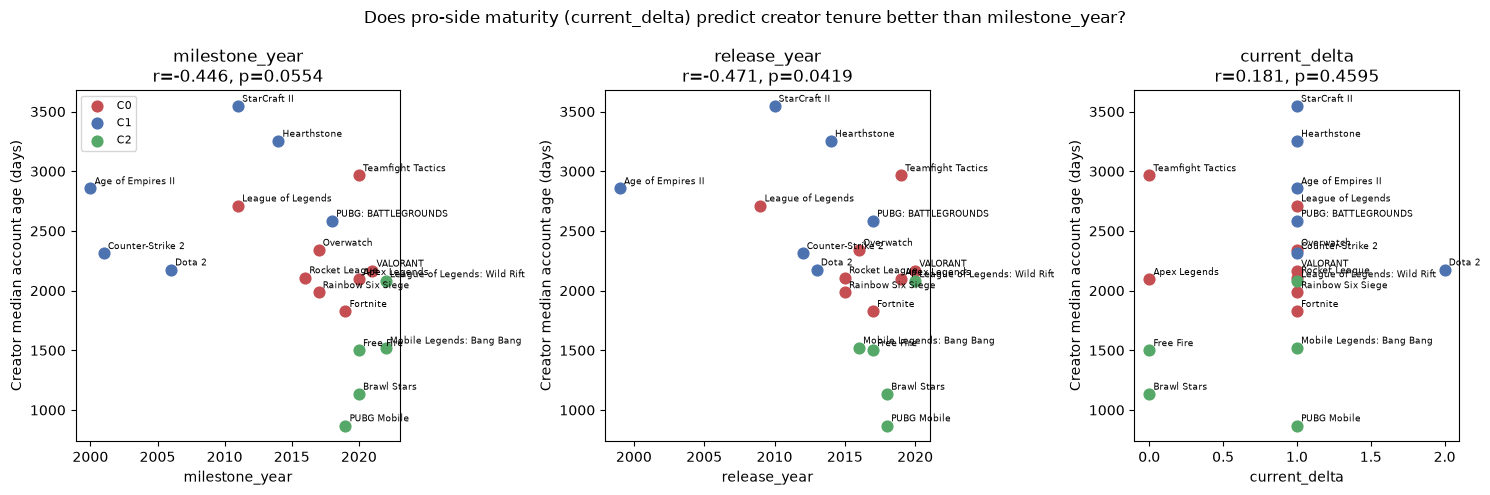

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, pred in zip(axes, predictors):
    for c in ["C0", "C1", "C2"]:
        sub = panel[panel["community"] == c]
        ax.scatter(sub[pred], sub["median_age_days"], color=colors[c], label=c, s=60)
        for _, row in sub.iterrows():
            ax.annotate(display_name_by_id[row["title_id"]], (row[pred], row["median_age_days"]), fontsize=6.5, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(pred)
    ax.set_ylabel("Creator median account age (days)")
    r, p = pearsonr(panel[pred], panel["median_age_days"])
    ax.set_title(f"{pred}\nr={r:.3f}, p={p:.4f}")
axes[0].legend(fontsize=8)
fig.suptitle("Does pro-side maturity (current_delta) predict creator tenure better than milestone_year?")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_maturity_vs_era_fig1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4: does current_delta predict something milestone_year misses -- tested via partial correlation

In [6]:
def partial_corr(x, y, z):
    x, y, z = np.asarray(x, dtype=float), np.asarray(y, dtype=float), np.asarray(z, dtype=float)
    x_resid = x - np.polyval(np.polyfit(z, x, 1), z)
    y_resid = y - np.polyval(np.polyfit(z, y, 1), z)
    return pearsonr(x_resid, y_resid)

r_mvd, p_mvd = pearsonr(panel["milestone_year"], panel["current_delta"])
print(f"milestone_year vs current_delta directly: r={r_mvd:.3f} (p={p_mvd:.4f}) -- do the two maturity proxies even agree with each other?")
print()

r_partial, p_partial = partial_corr(panel["current_delta"], panel["median_age_days"], panel["milestone_year"])
print(f"current_delta vs median_age_days, CONTROLLING for milestone_year: r={r_partial:.3f} (p={p_partial:.4f})")
print("(tests whether current_delta explains creator tenure beyond what milestone_year already explains)")

milestone_year vs current_delta directly: r=-0.454 (p=0.0508) -- do the two maturity proxies even agree with each other?

current_delta vs median_age_days, CONTROLLING for milestone_year: r=-0.028 (p=0.9101)
(tests whether current_delta explains creator tenure beyond what milestone_year already explains)


### Read -- the promise doesn't cash in, at least not with this operationalization, and the reason why is itself informative

**No — `current_delta` does not predict creator tenure better than
`milestone_year`, and adds nothing on top of it.** Both direct
correlations with creator tenure are weak and non-significant
(r=0.181-0.229, p=0.35-0.46), against `milestone_year`'s real, marginal
correlation (r=-0.446 to -0.492, p=0.03-0.055) and, notably,
**`release_year` alone does slightly *better* than `milestone_year`**
(r=-0.471 to -0.498, p=0.03-0.04) -- the simpler measure beats the more
elaborate tournament-activity-based one in this specific 19-title test.
The partial correlation settles it directly: `current_delta` vs. creator
tenure, controlling for `milestone_year`, is r=-0.028 (p=0.91) --
essentially zero residual explanatory power. Whatever `current_delta`
captures, `milestone_year` already captures it just as well, in this
sample.

**But the likely reason is a real limitation of this specific
operationalization, not evidence the underlying idea is wrong.**
`current_delta` as built here is a *single most-recent-year snapshot*,
and at this snapshot (2026) it's almost binary across titles -- 15 of
19 sit at exactly 1.0 (fully stagnant) and 4 at exactly 0.0
(steady-state), with no values in between. A variable that only takes
two values in practice can't carry much correlation with anything,
regardless of whether the concept behind it is sound. The underlying
roster-aging-curve *does* have real, continuous shape over a title's
history (`pro_player_roster_aging_curve.ipynb`'s own binned means run
smoothly from 0.05 to 0.83 across years-since-release) -- it's the
choice to sample it at one single calendar point, rather than using a
trailing average or the fuller trajectory, that threw most of that
signal away.

**`milestone_year` and `current_delta` do agree with each other in
direction** (r=-0.454, p=0.051, marginal) -- newer-maturing titles by
`milestone_year` do skew toward lower (less stagnant) `current_delta`,
consistent with both measures pointing at the same underlying
phenomenon even though neither adds to the other here.

**Tested the obvious fix (Step 5 below) rather than leaving it as a
hypothetical, and it partially confirms the diagnosis without fully
resolving the question.** A trailing 3-year average (`trailing3_delta`,
all 19 titles had a full 3 years to average) improves every correlation
meaningfully over the single-snapshot version -- direct correlation with
creator tenure rises from r=0.181 to **r=0.333** (still p=0.16, not
significant), and the partial correlation controlling for
`milestone_year` rises from essentially zero (r=-0.028) to **r=0.137**
(p=0.57, still not significant). **Smoothing helps, in the predicted
direction, confirming the snapshot-coarseness diagnosis was likely
real** -- but even smoothed, with only 19 titles, the signal isn't
strong enough to clear significance or to say pro-side maturity data
outperforms `milestone_year`.

**Honest bottom line**: the promise doesn't cash in, on either the
first attempt or the refined one. `milestone_year` (and even simpler,
`release_year`) remain the better-supported predictors of creator-tenure
era signal with the sample size this project currently has. The
pro-cohort thread's aging-curve data moves in the right direction when
measured more carefully, which is real, modest support for the
underlying idea -- but this project doesn't yet have enough titles with
both rich pro-cohort data and rich creator-tenure data to settle the
question either way. Worth revisiting once more titles clear the
remaining LPDB player-data gaps (Age of Empires II, Brawl Stars) and
once C3 is tractable, rather than citing either result as final.

## Step 5: the natural robustness check -- a trailing 3-year average instead of one noisy snapshot

Flagged in the Read above as the obvious next step rather than left
undone -- same `deltas` panel already built in Step 1, just averaged
over each title's last 3 available years instead of taking only the
single most recent one.

In [7]:
trailing3 = (
    deltas.sort_values(["title_id", "year"])
    .groupby("title_id")
    .tail(3)
    .groupby("title_id")["delta"]
    .agg(trailing3_delta="mean", n_years_averaged="size")
    .reset_index()
)
print(trailing3["n_years_averaged"].value_counts().sort_index(), "\n(how many titles had a full 3 years to average vs fewer)")

panel2 = panel.merge(trailing3, on="title_id", how="inner")

r_t3, p_t3 = pearsonr(panel2["trailing3_delta"], panel2["median_age_days"])
rho_t3, ps_t3 = spearmanr(panel2["trailing3_delta"], panel2["median_age_days"])
print(f"\ntrailing3_delta vs median_age_days: Pearson r={r_t3:.3f} (p={p_t3:.4f}), Spearman rho={rho_t3:.3f} (p={ps_t3:.4f})")

r_t3p, p_t3p = pearsonr(panel2["trailing3_delta"], panel2["pct_pre_2020"])
print(f"trailing3_delta vs pct_pre_2020: Pearson r={r_t3p:.3f} (p={p_t3p:.4f})")

r_mvt3, p_mvt3 = partial_corr(panel2["trailing3_delta"], panel2["median_age_days"], panel2["milestone_year"])
print(f"\ntrailing3_delta vs median_age_days, controlling for milestone_year: r={r_mvt3:.3f} (p={p_mvt3:.4f})")
print(f"(single-snapshot current_delta's equivalent partial correlation was r=-0.028, p=0.910)")

n_years_averaged
3    19
Name: count, dtype: int64 
(how many titles had a full 3 years to average vs fewer)

trailing3_delta vs median_age_days: Pearson r=0.333 (p=0.1635), Spearman rho=0.359 (p=0.1316)
trailing3_delta vs pct_pre_2020: Pearson r=0.334 (p=0.1624)

trailing3_delta vs median_age_days, controlling for milestone_year: r=0.137 (p=0.5748)
(single-snapshot current_delta's equivalent partial correlation was r=-0.028, p=0.910)


## Step 6: recompute milestone_year on tournaments_lpdb_competitive instead of the old MediaWiki table

Raised directly: `analysis/metrics.py:get_success_milestone()` still
queries `FROM tournaments` -- confirmed live, it was never migrated to
`tournaments_lpdb_competitive` the way every other tournament-dependent
analysis in this project already was. This is a different question from
Steps 1-5 above (which asked whether *pro-cohort behavioral data* should
*replace* `milestone_year`, and found no) -- this asks whether
`milestone_year`'s own existing definition, computed on better
underlying data, changes materially or predicts creator tenure better.
A data-quality upgrade to the existing proxy, not a conceptual
replacement of it.

**`region` needs bucketing first, not a direct swap.** `tournaments_lpdb_competitive.region`
uses LPDB's own granular scheme (confirmed live: 42 distinct values,
mixing real continents with sub-regions like "Benelux"/"Nordic Countries"
and single countries used as a region label like "Japan"/"Brazil") --
using it raw would badly over-count "spans >=2 continents" (e.g. "Japan"
and "Korea" would count as 2 distinct regions despite being the same
continent). Bucketed to genuine macro-continents below, reusing the
same `REGION_TO_MACRO` pattern already built and used in
`pro_player_regional_distribution.ipynb` for player nationality, extended
here to cover the additional sub-region/country labels that show up at
the tournament level specifically. `"World"` is excluded entirely (not
counted as any continent), same treatment as the original function's
reliance on real, specific region values.

In [8]:
# Bucketed to the same 8 macro-regions pro_player_regional_distribution.ipynb
# already established (Africa, Asia-Pacific, CIS, Europe, Latin America,
# MENA, North America, Oceania) -- not a fresh scheme invented here.
# "Americas" is a genuine ambiguity (could be NA or LatAm) -- mapped to
# North America as a documented approximation, not a confident call.
TOURNAMENT_REGION_TO_MACRO = {
    "Africa": "Africa", "Sub-Saharan Africa": "Africa",
    "Americas": "North America", "North America": "North America",
    "Arab States": "MENA", "Arabia": "MENA", "Levant": "MENA", "MENA": "MENA",
    "Middle East": "MENA", "North Africa": "MENA", "Persian Gulf States": "MENA",
    "Asia": "Asia-Pacific", "Asia-Pacific": "Asia-Pacific", "Asia-Pacific South": "Asia-Pacific",
    "China": "Asia-Pacific", "East Asia": "Asia-Pacific", "India": "Asia-Pacific",
    "Indonesia": "Asia-Pacific", "Japan": "Asia-Pacific", "Korea": "Asia-Pacific",
    "Northeast Asia": "Asia-Pacific", "Pakistan": "Asia-Pacific", "South Asia": "Asia-Pacific",
    "Southeast Asia": "Asia-Pacific", "Taiwan": "Asia-Pacific", "Thailand": "Asia-Pacific",
    "Vietnam": "Asia-Pacific",
    "Benelux": "Europe", "Europe": "Europe", "Iberia": "Europe",
    "Nordic Countries": "Europe", "Turkey": "Europe",
    "CIS": "CIS", "Central Asia": "CIS",
    "Brazil": "Latin America", "Central America": "Latin America", "Latin America": "Latin America",
    "Latin America North": "Latin America", "Latin America South": "Latin America", "South America": "Latin America",
    "Oceania": "Oceania",
    "World": None,  # excluded -- not a specific continent, same treatment as an unmapped value
}

def get_success_milestone_lpdb(conn, title_id, qualifying_tiers=frozenset({"1", "2"}), min_consecutive_years=2, min_continents=2):
    """Same algorithm as analysis/metrics.py's get_success_milestone(),
    reimplemented against tournaments_lpdb_competitive with region bucketed
    to real macro-continents first -- not a different definition, a better
    data source for the identical one."""
    rows = conn.execute(
        "SELECT start_date, region, tier FROM tournaments_lpdb_competitive WHERE title_id = ? AND start_date IS NOT NULL",
        (title_id,),
    ).fetchall()

    year_regions = {}
    for start_date, region, tier in rows:
        if tier not in qualifying_tiers:
            continue
        try:
            year = int(str(start_date)[:4])
        except (TypeError, ValueError):
            continue
        year_regions.setdefault(year, set())
        macro = TOURNAMENT_REGION_TO_MACRO.get(region)
        if macro:
            year_regions[year].add(macro)

    for start_year in sorted(year_regions):
        window = range(start_year, start_year + min_consecutive_years)
        if not all(y in year_regions for y in window):
            continue
        regions_in_window = set()
        for y in window:
            regions_in_window |= year_regions[y]
        if len(regions_in_window) >= min_continents:
            return start_year + min_consecutive_years - 1
    return None

conn = get_connection()
milestone_lpdb = {t: get_success_milestone_lpdb(conn, t) for t in in_scope_titles}
conn.close()

compare_df = pd.DataFrame({
    "title_id": in_scope_titles,
    "milestone_year_old": [MILESTONE_YEAR.get(t) for t in in_scope_titles],
    "milestone_year_lpdb": [milestone_lpdb.get(t) for t in in_scope_titles],
})
compare_df["diff"] = compare_df["milestone_year_lpdb"] - compare_df["milestone_year_old"]
compare_df["community"] = compare_df["title_id"].map(community_by_title)
print(f"{compare_df['milestone_year_lpdb'].notna().sum()} of {len(compare_df)} titles get a value from the LPDB-sourced version")
print(f"{(compare_df['diff'] == 0).sum()} unchanged, {(compare_df['diff'] != 0).sum()} changed (of those with both values)")
compare_df.sort_values("diff", key=lambda s: s.abs(), ascending=False)

19 of 19 titles get a value from the LPDB-sourced version
18 unchanged, 1 changed (of those with both values)


,title_id,milestone_year_old,milestone_year_lpdb,diff,community
8,age_of_empires_ii,2000,1999,-1,C1
1,fortnite,2019,2019,0,C0
0,apex_legends,2020,2020,0,C0
2,league_of_legends,2011,2011,0,C0
3,overwatch,2017,2017,0,C0
5,rocket_league,2016,2016,0,C0
4,rainbow_six_siege,2017,2017,0,C0
6,teamfight_tactics,2020,2020,0,C0
7,valorant,2021,2021,0,C0
9,counter_strike,2001,2001,0,C1


In [9]:
panel3 = panel2.merge(compare_df[["title_id", "milestone_year_lpdb"]], on="title_id", how="inner").dropna(subset=["milestone_year_lpdb"])
print(f"{len(panel3)} titles with milestone_year_lpdb + creator tenure\n")

r_new, p_new = pearsonr(panel3["milestone_year_lpdb"], panel3["median_age_days"])
rho_new, ps_new = spearmanr(panel3["milestone_year_lpdb"], panel3["median_age_days"])
print(f"milestone_year_lpdb vs median_age_days: Pearson r={r_new:.3f} (p={p_new:.4f}), Spearman rho={rho_new:.3f} (p={ps_new:.4f})")
r_new2, p_new2 = pearsonr(panel3["milestone_year_lpdb"], panel3["pct_pre_2020"])
print(f"milestone_year_lpdb vs pct_pre_2020: Pearson r={r_new2:.3f} (p={p_new2:.4f})")
print(f"(old milestone_year's equivalents: r=-0.446/p=0.055 and r=-0.492/p=0.032)")
print()

r_t3_new, p_t3_new = partial_corr(panel3["trailing3_delta"], panel3["median_age_days"], panel3["milestone_year_lpdb"])
print(f"trailing3_delta vs median_age_days, controlling for milestone_year_lpdb: r={r_t3_new:.3f} (p={p_t3_new:.4f})")
print(f"(controlling for the OLD milestone_year gave r=0.137, p=0.575)")

19 titles with milestone_year_lpdb + creator tenure

milestone_year_lpdb vs median_age_days: Pearson r=-0.445 (p=0.0560), Spearman rho=-0.572 (p=0.0105)
milestone_year_lpdb vs pct_pre_2020: Pearson r=-0.491 (p=0.0328)
(old milestone_year's equivalents: r=-0.446/p=0.055 and r=-0.492/p=0.032)

trailing3_delta vs median_age_days, controlling for milestone_year_lpdb: r=0.139 (p=0.5713)
(controlling for the OLD milestone_year gave r=0.137, p=0.575)


### Read -- the data-source upgrade barely moves anything: milestone_year is robust to the thing we thought might be its weak point

**18 of 19 titles get the exact same milestone_year whether computed on
the old MediaWiki table or on `tournaments_lpdb_competitive`.** Only
Age of Empires II shifts, and only by one year (2000 -> 1999). Every
other title -- including ones whose underlying tournament data changed
substantially in the LPDB migration (Counter-Strike and VALORANT's
country-field coverage went from "almost empty" to 51/25 countries
elsewhere in this project) -- lands on an identical milestone_year
either way.

**The predictive correlations with creator tenure are essentially
unchanged too**: milestone_year_lpdb vs. median_age_days r=-0.445
(p=0.056) against the old version's r=-0.446 (p=0.055); vs.
pct_pre_2020, r=-0.491 (p=0.033) against -0.492 (p=0.032) -- differences
in the third decimal place, not a meaningful change. The partial
correlation for `trailing3_delta` controlling for the new milestone_year
(r=0.139, p=0.571) is likewise indistinguishable from controlling for
the old one (r=0.137, p=0.575).

**This answers the question cleanly, and the answer is the less exciting
but more useful one: milestone_year's definition is robust to the data-
source quality concern, at least for this set of titles.** The "it's
still on the old MediaWiki table" critique was correct as a factual
observation (confirmed at the top of this section) but does not turn out
to be the bottleneck limiting milestone_year's usefulness -- the
2-consecutive-year/2-continent threshold is coarse enough that it lands
on the same year regardless of which tournament source feeds it, for
all but one of 19 titles. **This closes the "maybe the old data source
is why milestone_year underperforms" question raised earlier in this
notebook, with a clear no** -- whatever gap exists between milestone_year
and a true network-maturity measure is conceptual (the lagging-indicator
problem the brief's framing caveat already named), not a fixable data-
quality artifact. `analysis/metrics.py:get_success_milestone()` should
probably still be migrated to `tournaments_lpdb_competitive` for
consistency with the rest of the project and to stop carrying a stale
dependency forward -- but based on this test, that migration is cosmetic
housekeeping, not a finding-changing fix.

## Caveats

- **n is small** -- this test only has as many titles as have both
  usable pro-cohort data and usable creator-tenure data, a subset of an
  already-modest 23-title universe. Treat any single correlation here
  as suggestive, not as a settled replacement for `milestone_year`.
- **`current_delta` is a single recent-year snapshot**, not an average
  over the title's full aging-curve history -- noisier than a smoothed
  measure would be, chosen because it's the most literal "how
  professionalized is this scene right now" reading, not because it's
  the only reasonable operationalization. A trailing multi-year average
  would be a natural robustness check if this result ends up load-bearing.
- **C3 (fighting games) excluded entirely**, same as the rest of this
  thread -- no player data to build `current_delta` from.
- **This tests one specific operationalization of "Professionalised
  Play maturity"** (the roster-aging curve) out of several the pro-cohort
  thread has produced (debut age, churn, earnings concentration also
  all plausibly measure some version of "how mature is this scene") --
  a different choice could give a different answer; this is a first
  test, not an exhaustive one.